In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("C:/Users/DELL/Downloads/archive (1)/Bookings.csv")

In [3]:
data.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22 3:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02 9:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


In [4]:
data.shape

(103024, 21)

In [5]:
data.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images', 'Unnamed: 20'],
      dtype='object')

In [6]:
data.nunique()

Date                           40214
Time                            1440
Booking_ID                    103024
Booking_Status                     4
Customer_ID                    94544
Vehicle_Type                       7
Pickup_Location                   50
Drop_Location                     50
V_TAT                             40
C_TAT                             25
Canceled_Rides_by_Customer         5
Canceled_Rides_by_Driver           4
Incomplete_Rides                   2
Incomplete_Rides_Reason            3
Booking_Value                   2883
Payment_Method                     4
Ride_Distance                     50
Driver_Ratings                    21
Customer_Rating                   21
Vehicle Images                     1
Unnamed: 20                        0
dtype: int64

In [7]:
data['Date'].unique()

array(['2024-07-26 14:00:00', '2024-07-25 22:20:00',
       '2024-07-30 19:59:00', ..., '2024-07-31 1:32:00',
       '2024-07-31 23:14:00', '2024-07-31 9:19:00'],
      shape=(40214,), dtype=object)

In [8]:
data.isnull().sum()

Date                               0
Time                               0
Booking_ID                         0
Booking_Status                     0
Customer_ID                        0
Vehicle_Type                       0
Pickup_Location                    0
Drop_Location                      0
V_TAT                          39057
C_TAT                          39057
Canceled_Rides_by_Customer     92525
Canceled_Rides_by_Driver       84590
Incomplete_Rides               39057
Incomplete_Rides_Reason        99098
Booking_Value                      0
Payment_Method                 39057
Ride_Distance                      0
Driver_Ratings                 39057
Customer_Rating                39057
Vehicle Images                     0
Unnamed: 20                   103024
dtype: int64

In [9]:
data.drop(columns=['Unnamed: 20', 'Vehicle Images'], inplace=True)
data.drop_duplicates(inplace=True)

In [10]:
data["Canceled_Rides_by_Customer"]=data["Canceled_Rides_by_Customer"].fillna(0)
data["Canceled_Rides_by_Driver"]=data["Canceled_Rides_by_Driver"].fillna(0)

In [11]:
data["Driver_Ratings"]=data["Driver_Ratings"].fillna(0)
data["Customer_Rating"]=data["Customer_Rating"].fillna(0)

In [12]:
data["Payment_Method"]=data["Payment_Method"].fillna("Not Available")

In [13]:
data["V_TAT"]=data["V_TAT"].fillna(0)
data["C_TAT"]=data["C_TAT"].fillna(0)

In [14]:
data["Incomplete_Rides"]=data["Incomplete_Rides"].fillna(0)

In [15]:
data["Incomplete_Rides_Reason"]=data["Incomplete_Rides_Reason"].fillna(0)

In [16]:
data.isnull().sum()

Date                          0
Time                          0
Booking_ID                    0
Booking_Status                0
Customer_ID                   0
Vehicle_Type                  0
Pickup_Location               0
Drop_Location                 0
V_TAT                         0
C_TAT                         0
Canceled_Rides_by_Customer    0
Canceled_Rides_by_Driver      0
Incomplete_Rides              0
Incomplete_Rides_Reason       0
Booking_Value                 0
Payment_Method                0
Ride_Distance                 0
Driver_Ratings                0
Customer_Rating               0
dtype: int64

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       103024 non-null  float64
 9   C_TAT                       103024 non-null  float64
 10  Canceled_Rides_by_Customer  103024 non-null  object 
 11  Canceled_Rides_by_Driver    103024 non-null  object 
 12  Incomplete_Rides            103024 non-null  object 
 13  Incomplete_Rid

In [18]:
# Success Flag
data['Is_Success'] = data['Booking_Status'].apply(lambda x: 1 if x == 'Success' else 0)

# Cancellation Flag
data['Is_Cancelled'] = data['Booking_Status'].apply(lambda x: 1 if x != 'Success' else 0)

# Driver Cancellation
data['Driver_Cancel'] = data['Booking_Status'].apply(lambda x: 1 if x == 'Canceled by Driver' else 0)

# Customer Cancellation
data['Customer_Cancel'] = data['Booking_Status'].apply(lambda x: 1 if x == 'Canceled by Customer' else 0)
# Revenue
data['Revenue'] = data['Booking_Value']
# Revenue lost
data['Revenue_Lost'] = data.apply(lambda x: x['Booking_Value'] if x['Booking_Status'] != 'Success' else 0, axis=1)


In [19]:
total_bookings = data.shape[0]
successful_bookings = data['Is_Success'].sum()
cancellation_rate = data['Is_Cancelled'].mean() * 100
total_revenue = data['Revenue'].sum()
avg_booking_value = data['Revenue'].mean()
avg_distance = data['Ride_Distance'].mean()
avg_driver_rating = data['Driver_Ratings'].mean()
avg_customer_rating = data['Customer_Rating'].mean()

print("Total Bookings:", total_bookings)
print("Successful Bookings:", successful_bookings)
print("Cancellation Rate (%):", round(cancellation_rate,2))
print("Total Revenue:", total_revenue)
print("Average Booking Value:", round(avg_booking_value,2))
print("Average Distance:", round(avg_distance,2))
print("Average Driver Rating:", round(avg_driver_rating,2))
print("Average Customer Rating:", round(avg_customer_rating,2))


Total Bookings: 103024
Successful Bookings: 63967
Cancellation Rate (%): 37.91
Total Revenue: 56534614
Average Booking Value: 548.75
Average Distance: 14.19
Average Driver Rating: 2.48
Average Customer Rating: 2.48


In [20]:
data.columns = data.columns.str.strip()

In [21]:
data['Hour'] = pd.to_datetime(data['Time'], errors='coerce').dt.hour


C:\Users\DELL\AppData\Local\Temp\ipykernel_17228\1586559767.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Hour'] = pd.to_datetime(data['Time'], errors='coerce').dt.hour


In [22]:
data['Hour'].head()


0    14
1    22
2    19
3     3
4     9
Name: Hour, dtype: int32

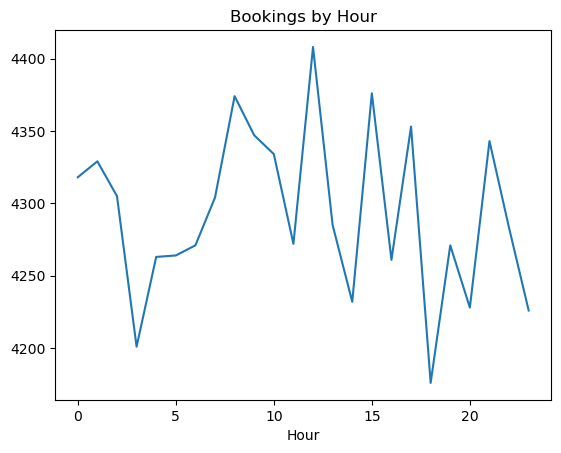

In [23]:
# Booking by hour
data.groupby('Hour')['Booking_ID'].count().plot(kind='line')
plt.title("Bookings by Hour")
plt.show()

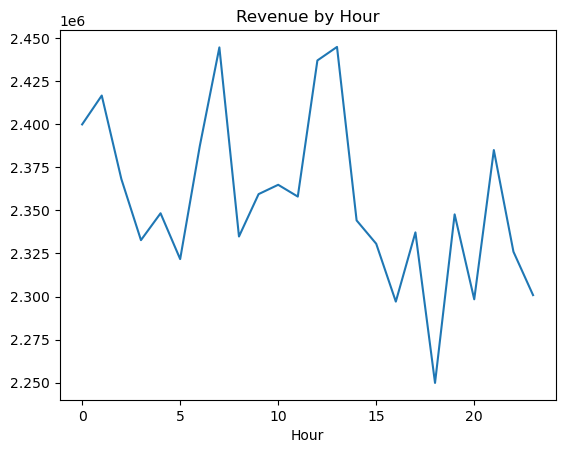

In [24]:
#  Revenue by Hour 
data.groupby('Hour')['Revenue'].sum().plot(kind='line')
plt.title("Revenue by Hour")
plt.show()


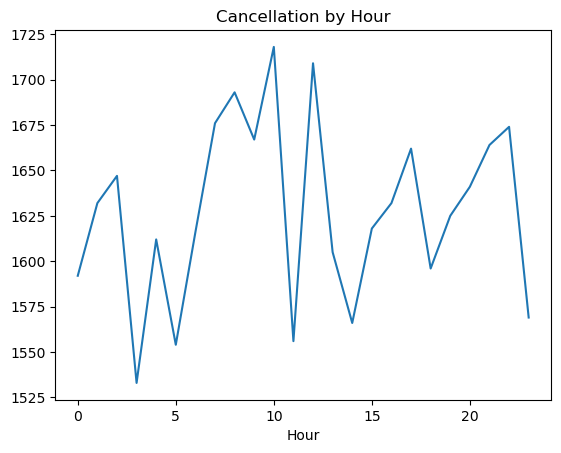

In [25]:
# Cencellation by Hour
data.groupby('Hour')['Is_Cancelled'].sum().plot(kind='line')
plt.title("Cancellation by Hour")
plt.show()



In [26]:
# Vehicle Type analysis
vehicle_analysis=data.groupby('Vehicle_Type').agg({
    'Booking_ID':'count',
    'Revenue':'sum',
    'Is_Cancelled':'sum',
    'Driver_Ratings':'mean',
    'Customer_Rating':'mean'
    
}).reset_index()
vehicle_analysis.rename(columns={'Booking_ID':'Total_Rides'}, inplace=True)

vehicle_analysis

,Vehicle_Type,Total_Rides,Revenue,Is_Cancelled,Driver_Ratings,Customer_Rating
0,Auto,14755,8092210,5588,2.487570,2.484385
1,Bike,14662,7987054,5528,2.482322,2.487757
2,Mini,14552,7990996,5516,2.479316,2.482374
3,Prime Plus,14707,8050889,5632,2.466846,2.474074
4,Prime SUV,14655,7933330,5659,2.458956,2.455026
5,Prime Sedan,14877,8298612,5498,2.515870,2.522747
6,eBike,14816,8181523,5636,2.482580,2.470876


In [27]:
vehicle_analysis['Cancellation_Rate_%'] = (
    vehicle_analysis['Is_Cancelled'] / vehicle_analysis['Total_Rides']
) * 100

vehicle_analysis

,Vehicle_Type,Total_Rides,Revenue,Is_Cancelled,Driver_Ratings,Customer_Rating,Cancellation_Rate_%
0,Auto,14755,8092210,5588,2.487570,2.484385,37.871908
1,Bike,14662,7987054,5528,2.482322,2.487757,37.702905
2,Mini,14552,7990996,5516,2.479316,2.482374,37.905443
3,Prime Plus,14707,8050889,5632,2.466846,2.474074,38.294690
4,Prime SUV,14655,7933330,5659,2.458956,2.455026,38.614807
5,Prime Sedan,14877,8298612,5498,2.515870,2.522747,36.956376
6,eBike,14816,8181523,5636,2.482580,2.470876,38.039957


In [28]:
# Top pick locations
data['Pickup_Location'].value_counts().head(10)


Pickup_Location
Banashankari        2201
Yeshwanthpur        2139
RT Nagar            2135
Indiranagar         2133
Sahakar Nagar       2126
Basavanagudi        2120
Ramamurthy Nagar    2116
Vijayanagar         2113
Tumkur Road         2105
Cox Town            2100
Name: count, dtype: int64

In [29]:
# Revenue by pickup location
data.groupby('Pickup_Location')['Revenue'].sum().sort_values(ascending=False).head(10)


Pickup_Location
RT Nagar        1225150
Banashankari    1220409
Nagarbhavi      1211057
Yeshwanthpur    1188522
Frazer Town     1175684
Hosur Road      1168154
Tumkur Road     1166372
Basavanagudi    1165243
Cox Town        1163196
JP Nagar        1159478
Name: Revenue, dtype: int64

In [30]:
revenue_loss_summary = data.groupby('Hour').agg({
    'Revenue_Lost':'sum',
    'Is_Cancelled':'sum'
}).reset_index()

revenue_loss_summary

,Hour,Revenue_Lost,Is_Cancelled
0,0,907828,1592
1,1,928556,1632
2,2,889090,1647
3,3,838817,1533
4,4,892440,1612
5,5,861209,1554
6,6,909945,1616
7,7,963062,1676
8,8,912593,1693
9,9,921539,1667


In [31]:
# success rate by hour 
success_hour = data.groupby('Hour')['Is_Success'].mean().reset_index()

success_hour['Success_Rate_%'] = success_hour['Is_Success'] * 100

success_hour

,Hour,Is_Success,Success_Rate_%
0,0,0.631311,63.131079
1,1,0.623008,62.300762
2,2,0.617422,61.742160
3,3,0.635087,63.508688
4,4,0.621863,62.186254
5,5,0.635553,63.555347
6,6,0.621634,62.163428
7,7,0.610595,61.059480
8,8,0.612940,61.294010
9,9,0.616517,61.651714


In [32]:
# Distance category performance 
data['Distance_Category'] = pd.cut(
    data['Ride_Distance'],
    bins=[-1,5,15,30,100],
    labels=['Short','Medium','Long','Very Long']
)

In [33]:
distance_summary = data.groupby('Distance_Category').agg({
    'Booking_ID':'count',
    'Revenue':'sum',
    'Is_Cancelled':'sum'
}).reset_index()

distance_summary.rename(columns={'Booking_ID':'Total_Rides'}, inplace=True)

distance_summary

C:\Users\DELL\AppData\Local\Temp\ipykernel_17228\2943289892.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_summary = data.groupby('Distance_Category').agg({


,Distance_Category,Total_Rides,Revenue,Is_Cancelled
0,Short,47099,25906132,39057
1,Medium,15925,8680387,0
2,Long,18675,10182591,0
3,Very Long,21325,11765504,0


In [34]:
print(data.columns)

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Is_Success', 'Is_Cancelled', 'Driver_Cancel', 'Customer_Cancel',
       'Revenue', 'Revenue_Lost', 'Hour', 'Distance_Category'],
      dtype='object')


In [35]:
data['Revenue_per_Ride'] = data['Revenue'] / data['Booking_ID'].count()

In [36]:
data.to_csv("ola_final_eda.csv", index=False)

vehicle_analysis.to_csv("vehicle_summary.csv", index=False)
revenue_loss_summary.to_csv("hourly_revenue_loss.csv", index=False)
success_hour.to_csv("hourly_success_rate.csv", index=False)
distance_summary.to_csv("distance_summary.csv", index=False)

In [38]:
data.to_csv(r"C:\Users\DELL\Desktop\ola_final_eda.csv", index=False)